In [1]:
from __future__ import annotations

import json
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, TypedDict

import duckdb
import pandas as pd

from IPython.display import Image, display
from langchain_core.messages import (
    BaseMessage,
    HumanMessage,
    SystemMessage,
    AIMessage,
    ToolMessage,
)
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END

In [2]:
#DB_PATH = Path("./database/shop.duckdb").resolve()   # <-- change if needed
DB_PATH = Path("../../garvis-backend/data/garvis.duckdb").resolve()   # <-- change if needed

OUT_DIR = Path("./out").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

if not DB_PATH.exists():
    raise FileNotFoundError(
        f"DuckDB file not found at {DB_PATH}. "
        "Run your one-time creation script first."
    )

print("Using DB:", DB_PATH)
print("Output folder:", OUT_DIR)

Using DB: /media/SN850X-A/vscode/kaggle/garvis/garvis-backend/data/garvis.duckdb
Output folder: /media/SN850X-A/vscode/kaggle/garvis/langgraph-lab/03. duck-db-integration/out


In [3]:
DISALLOWED = re.compile(
    r"\b(INSERT|UPDATE|DELETE|DROP|ALTER|CREATE|REPLACE|TRUNCATE|ATTACH|DETACH|COPY|EXPORT)\b",
    re.I,
)

def validate_select_only(sql: str) -> Optional[str]:
    sql = sql.strip().rstrip(";")
    if not sql:
        return "SQL is empty."
    if DISALLOWED.search(sql):
        return "Only read-only SELECT queries are allowed."
    if ";" in sql:
        return "Only a single SQL statement is allowed."
    if not re.match(r"^\s*SELECT\b", sql, re.I):
        return "Only SELECT queries are allowed."
    return None

def ensure_limit(sql: str, default_limit: int = 200) -> str:
    if re.search(r"\bLIMIT\b", sql, re.I):
        return sql
    return f"{sql.rstrip(';')}\nLIMIT {default_limit}"

In [ ]:
def connect_db(db_path: Path) -> duckdb.DuckDBPyConnection:
    return duckdb.connect(str(db_path))

In [ ]:
@dataclass
class DBConfig:
    db_path: Path

db_cfg = DBConfig(db_path=DB_PATH)

def build_tools(db_cfg: DBConfig):
    @tool
    def list_tables() -> List[str]:
        """List available tables in the DuckDB database."""
        con = connect_db(db_cfg.db_path)
        try:
            df = con.sql("SHOW TABLES").df()
            return df["name"].tolist() if not df.empty else []
        finally:
            con.close()

    @tool
    def get_table_schema(table_name: str) -> str:
        """Get the schema (columns and types) for a given table."""
        con = connect_db(db_cfg.db_path)
        try:
            df = con.sql(f"PRAGMA table_info('{table_name}')").df()
            if df.empty:
                return f"No such table: {table_name}"
            cols = [f"{row['name']} {row['type']}" for _, row in df.iterrows()]
            return f"{table_name}({', '.join(cols)})"
        finally:
            con.close()

    @tool
    def run_sql(query: str) -> Dict[str, Any]:
        """
        Execute a read-only SELECT query and return a preview (first ~20 rows) plus metadata.
        """
        err = validate_select_only(query)
        if err:
            return {"error": err}

        print(f"==================\n\nQuery:{query}\n\n==================")
        
        q = ensure_limit(query, default_limit=400)

        con = connect_db(db_cfg.db_path)
        try:
            df = con.sql(q).df()
            preview_rows = df.head(20).to_dict(orient="records")
            return {
                "columns": list(df.columns),
                "rows_preview": preview_rows,
                "row_count_preview": int(len(df)),
                "note": "Preview is limited. Use save_query_to_csv to export full results (consider adding LIMIT).",
            }
        finally:
            con.close()

    @tool
    def save_query_to_csv(query: str, csv_path: str) -> Dict[str, Any]:
        """
        Execute a read-only SELECT query and save the full result to csv_path.
        Creates parent directories if needed.
        """
        err = validate_select_only(query)
        if err:
            return {"error": err}

        out_path = Path(csv_path)
        out_path.parent.mkdir(parents=True, exist_ok=True)

        con = connect_db(db_cfg.db_path)
        try:
            df = con.sql(query.strip().rstrip(";")).df()
            #df.to_csv(out_path, index=False)
            return {
                #"saved_to": str(out_path.resolve()),
                "rows": int(len(df)),
                "columns": list(df.columns),
            }
        finally:
            con.close()

    return [list_tables, get_table_schema, run_sql, save_query_to_csv] #$
    #return [list_tables, get_table_schema, run_sql]

tools = build_tools(db_cfg)
tool_by_name = {t.name: t for t in tools}

[t.name for t in tools]

['list_tables', 'get_table_schema', 'run_sql', 'save_query_to_csv']

In [6]:
from dotenv import load_dotenv

load_dotenv()

True

In [7]:
SYSTEM_PROMPT = """
You are a SQL assistant for a DuckDB database.

Process:
1) Call list_tables() to get the names of the tables and have an idea what data is contained in the tables.
2) Call get_table_schema() for relevant tables to get the table structure of the tables, with the field names and datatypes.
3) Propose a single read-only SELECT ANSI-SQL compliant query.
4) Call run_sql(query) to validate it and inspect a preview.
5) Call save_query_to_csv(query, csv_path) to save the result to a local CSV file.
6) Provide a concise final answer, and include the saved CSV path.

Rules:
- Read-only SELECT queries only.
- Prefer explicit joins using the foreign keys:
  customer_orders.customer_id -> customers.customer_id
  customer_orders.order_id    -> orders.order_id
- If the user does not specify an output path, choose: ./out/query_result.csv
"""

model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

In [8]:
class AgentState(TypedDict):
    messages: List[BaseMessage]

def assistant_node(state: AgentState) -> Dict[str, Any]:
    msgs = state["messages"]
    resp = model.bind_tools(tools).invoke(msgs)  # bind_tools supported per ChatOpenAI reference :contentReference[oaicite:5]{index=5}
    return {"messages": msgs + [resp]}

def tools_node(state: AgentState) -> Dict[str, Any]:
    msgs = state["messages"]
    last = msgs[-1]

    if(not isinstance(last, AIMessage) or not last.tool_calls):
        return {"messages": msgs}

    tool_messages: List[ToolMessage] = []
    for call in last.tool_calls:
        name = call["name"]
        args = call.get("args", {}) or {}
        tool_obj = tool_by_name.get(name)
        
        if tool_obj is None:
            tool_messages.append(ToolMessage(content=f"Unknown tool: {name}", tool_call_id=call["id"]))
            continue
        try:
            print(f"name: {name}| args: {args}")
            
            result = tool_obj.invoke(args)
        except Exception as e:
            result = {"error": f"Tool execution error: {e}"}

        tool_messages.append(
            ToolMessage(content=json.dumps(result, default=str), tool_call_id=call["id"])
        )

    return {"messages": msgs + tool_messages}

def route(state: AgentState) -> str:
    last = state["messages"][-1]
    if isinstance(last, AIMessage) and last.tool_calls:
        return "tools"
    return "end"

In [9]:
g = StateGraph(AgentState)
g.add_node("assistant", assistant_node)
g.add_node("tools", tools_node)

g.add_edge(START, "assistant")
g.add_conditional_edges("assistant", route, {"tools": "tools", "end": END})
g.add_edge("tools", "assistant")

agent = g.compile()

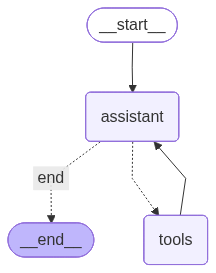

In [10]:
display(Image(agent.get_graph().draw_mermaid_png()))

In [11]:
def ask(question: str, out_csv: str | Path = OUT_DIR / "query_result.csv") -> str:
    out_csv = Path(out_csv)
    out_csv.parent.mkdir(parents=True, exist_ok=True)

    initial_messages: List[BaseMessage] = [
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=f"{question}\n\nSave results to CSV path: {out_csv.as_posix()}"),
    ]

    result_state = agent.invoke({"messages": initial_messages})

    #print(f"======================================\n\n{result_state["messages"]}\n\n===================")
    
    # Return the last assistant message that is NOT a tool call
    for m in reversed(result_state["messages"]):
        print(m)
        if isinstance(m, AIMessage) and not m.tool_calls:
            return m.content        

    return "(No final answer produced.)"

In [ ]:
def running_agent():
    print("**** RAG AGENT ****")

    while(True):
        user_input = input("\n\nWhat is your question?:")

        if(user_input.lower() in ["exit","quit"]):
            break

        result = ask(user_input, OUT_DIR / "customer_spend.csv")
            
        print("\n\n**** ANSWER ****")
        print(result)

running_agent()
print("BYE!")

**** RAG AGENT ****




What is your question?: how many doctors are there?


name: list_tables| args: {}
name: get_table_schema| args: {'table_name': 'doctor'}
name: run_sql| args: {'query': 'SELECT COUNT(*) AS number_of_doctors FROM doctor'}

Query:SELECT COUNT(*) AS number_of_doctors FROM doctor

name: save_query_to_csv| args: {'query': 'SELECT COUNT(*) AS number_of_doctors FROM doctor', 'csv_path': '/media/SN850X-A/vscode/kaggle/garvis/langgraph-lab/03. duck-db-integration/out/customer_spend.csv'}
content='There are 100 doctors in the database.\n\nThe result has been saved to the CSV file at: /media/SN850X-A/vscode/kaggle/garvis/langgraph-lab/03. duck-db-integration/out/customer_spend.csv' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 702, 'total_tokens': 754, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'm

KeyboardInterrupt: Interrupted by user